In [ ]:
!pip install sentence-transformers seaborn

In [ ]:
from sentence_transformers import SentenceTransformer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('all-MiniLM-L6-v2')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
sentences = [

# Cricket
"The batsman scored a century in the match",
"The bowler delivered a fast yorker",
"The cricket team won the world cup",

# Cooking
"I am preparing pasta with tomato sauce",
"The chef is baking a chocolate cake",
"Cooking vegetables with olive oil improves flavor",

# Cybersecurity
"The hacker attempted to breach the system",
"Strong passwords improve cybersecurity",
"Firewalls help protect networks from attacks",

# Extra sentence
"Data encryption protects sensitive information"

]

len(sentences)


10

In [ ]:
embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)


Embedding shape: (10, 384)


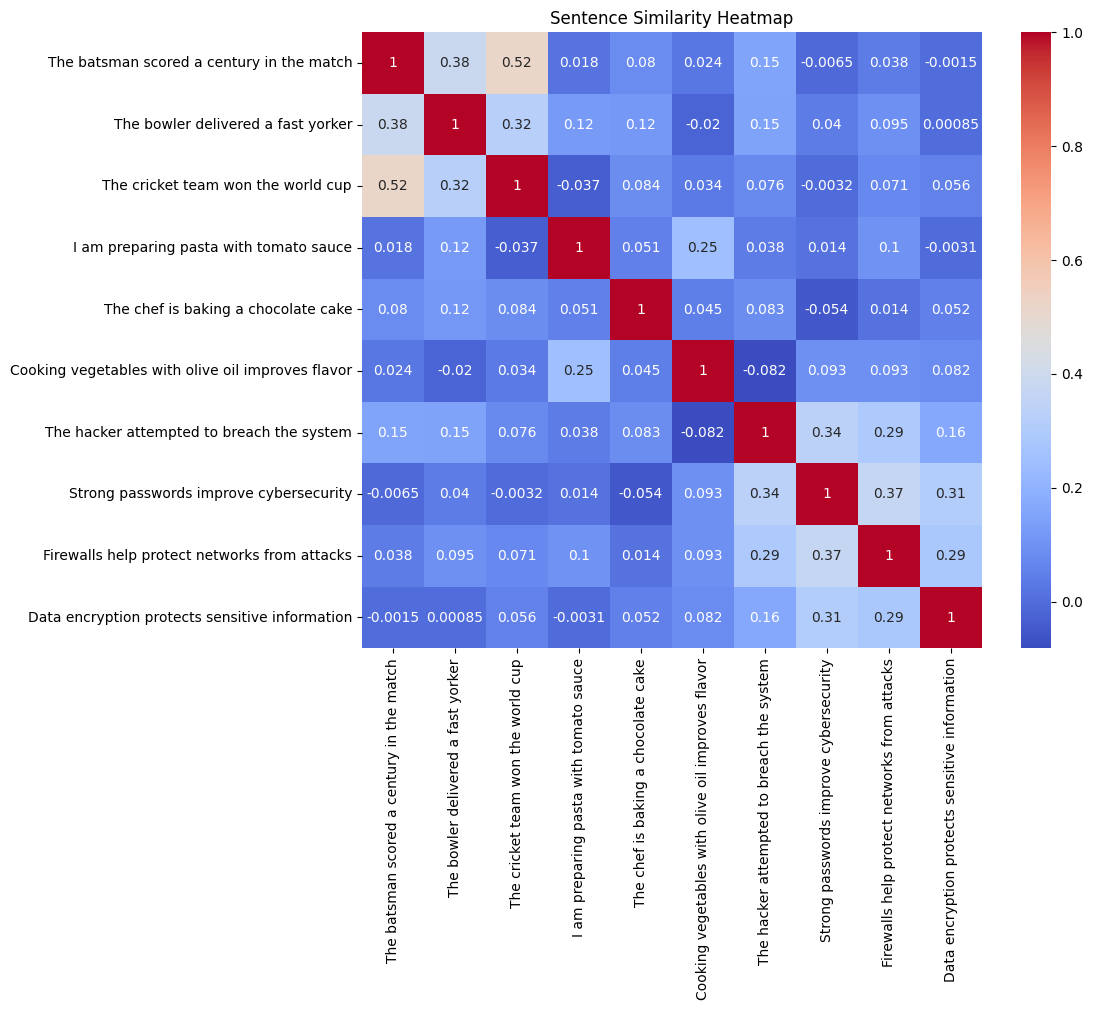

In [ ]:
similarity_matrix = cosine_similarity(embeddings)

similarity_df = pd.DataFrame(similarity_matrix, index=sentences, columns=sentences)

plt.figure(figsize=(10,8))
sns.heatmap(similarity_df, annot=True, cmap="coolwarm")
plt.title("Sentence Similarity Heatmap")
plt.show()

In [ ]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

results = list(zip(sentences, similarities))

results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

print("Top 2 most similar sentences:\n")

for sentence, score in results_sorted[:2]:
    print(sentence, "-> Similarity Score:", score)

Top 2 most similar sentences:

The batsman scored a century in the match -> Similarity Score: 0.5682197
The bowler delivered a fast yorker -> Similarity Score: 0.54138273
